<a href="https://colab.research.google.com/github/Denaro13/New-Hybrid-Block-Collocation-Method-Elliptic-PDEs/blob/main/New_Hybrid_Block_Collocation_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Block Collocation Method
NHBCM (New Hybrid Block Collocation Method) Implementation
For solving elliptic PDEs:

$$b1*u_xx + b2*u_yy + b3*u_x + b4*u_y + b5*u = g(x,y)$$

Test Problem 1: Poisson Equation

Test Problem 2: Helmholtz Equation

In [2]:
import numpy as np
from scipy.optimize import fsolve
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### Test Problem 1: POISSON EQUATION

PDE: $\frac{\partial^{2}u}{\partial x ^{2}}+\frac{\partial^{2}u}{\partial y ^{2}} = xe^{y}$

Domain: $[0, 2]\times [0, 1]$

Exact Solution: $u(x,y)=xe^{y}$

In [3]:
class PoissonProblem:

    def __init__(self, N_x=10, N_y=5):
        """
        N_x: number of divisions in x-direction
        N_y: number of divisions in y-direction
        """

        self.N_x = N_x
        self.N_y = N_y
        self.x_min, self.x_max = 0, 2
        self.y_min, self.y_max = 0, 1

        # Create grids
        self.x = np.linspace(self.x_min, self.x_max, N_x + 1)
        self.y = np.linspace(self.y_min, self.y_max, N_y + 1)
        self.dx = self.x[1] - self.x[0]
        self.dy = self.y[1] - self.y[0]

        print(f"Problem 1 setup")
        print(f" Domain: [{self.x_min}, {self.x_max}] x [{self.y_min}, {self.y_max}]")
        print(f" Grid: {N_x+1} x {N_y+1} points")
        print(f" Step sizes: dx = {self.dx:.4f}, dy: {self.dy:.4f}")

    def exact_solution(self, x, y):
      """Exact solution: u(x,y) = x*exp(y)"""
      return x * np.exp(y)

    def boundary_conditions(self):
      """Apply Dirichlet boundary condtions"""
      u_boundary = np.zeros((len(self.x), len(self.y)))

      # Bottom Boundar: u(x, 0) =0
      u_boundary[:, 0] = 0

      # Top boundary: u(x, 1) = x*exp(1)
      u_boundary[:, -1] = self.x * np.exp(1)

      # Left boundary: u(0, y) = 0
      u_boundary[0, :] = 0

      # Right boundary: u(2, y) = 2*exp(y)
      u_boundary[-1, :] = 2 * np.exp(self.y)

      return u_boundary

    def ode_rhs(self, x_idx, y, u_at_y):
      """
      Right-hand side of ODE after MOL transformation

      After MOL, we habe d²u_i/dy² = f(y, u_i, others)

      where f = x_i*exp(y) - [u_{i+1}] - 2*u_i + u_{i-1}]/dx²
      """

      u = u_at_y # u[i] is solution at x_i

      # Finite difference approximation of d²u/dx²

      if x_idx == 0 or x_idx == len(self.x) -1:
        # Boundary points
        d2u_dx2 = 0
      else:
        d2u_dx2 = (u[x_idx + 1] - 2*u[x_idx] + u[x_idx - 1]) / (self.dx**2)

      # Right-hand side
      source = self.x[x_idx] + np.exp(y)

      # ODE: u'' = source - d²u/dx²
      f = source - d2u_dx2
      return f

# NHBCM SOLVER

In [7]:
class NHBCMSolver:
  """
  Solver using NHBCM for 2D elliptic PDEs
  """

  def __init__(self, problem):
    """
    problem: PoissonProblem or HelmholtzProblem instance
    """

    self.problem = problem

    # NHBCM collocation points
    self.v1 = 1/3 # at 1/3 of step
    self.v2 = 1/2 # at 1/2 of step
    self.v3 = 4/5 # at 4/5 of step

    # Coefficients in main formular (from paper equations 10-12)
    # Note: These are pre-computed coefficients for the basis functions
    self.init_coefficients()

  def init_coefficients(self):
    """
    Pre-computed coefficients for NHBCM formulars
    (From the accessed paper, equations 10-12)
    """

    # For main step (y_{n+1})
    self.c_main = {
        'u': [1, -84/5040, 483/5040, 625/5040, -448/5040, 1944/5040],
        'u_prime': [1, 14/336, 35/336, 125/336, 162/336],
    }

  def solve_ivp_simple(self):
    """
    Simple solver: use finite differences throughout
    This is a baseline before implementing full NHBCM
    """

    N_x, N_y = self.problem.N_x, self.problem.N_y
    dx, dy = self.problem.dx, self.problem.dy

    # Initialize solution
    u = np.zeros((N_x + 1, N_y + 1))

    # Apply boundary conditions
    u_bc = self.problem.boundary_conditions()
    u[:, 0] = u_bc[:, 0] # bottom
    u[:, -1] = u_bc[:, -1] # top
    u[0, :] = u_bc[0, :] # left
    u[-1, :] = u_bc[-1, :] # right

    # Iterative method: solve interior points using finite difference
    max_iter = 10000
    tol = 1e-10

    for iteration in range(max_iter):
      u_old = u.copy()

      # Update interiror points using 5-point stencil
      for i in range(1, N_x):
        for j in range(1, N_y):
          # Laplace operator: u_xx +u_yy = f
          # Central differences: [u_i+1,j - 2 * u_ij + u_i-1,j]/dx² + [u_i,j+1 - 2*u_ij + u_i,j-1]dy² = f_ij

          if isinstance(self.problem, PoissonProblem):
            f = self.problem.x[i] * np.exp(self.problem.y[j])
            #Simple Poissom
            u[i,j] = (
                (u[i+1, j] + u[i-1, j])/dx**2 +
                (u[i, j+1] + u[i, j-1])/dy**2 -
                f
            ) / (2/dx**2 + 2/dy**2)

          elif isinstance(self.problem, HelmholtzProblem):
              f = self.problem.source_term(self.problem.x[i], self.problem.y[j])
              # Helmholtz: u_xx + u_yy + k*u = f
              u[i,j] = (
                (u[i+1, j] + u[i-1, j])/dx**2 +
                (u[i, j+1] + u[i, j-1])/dy**2 -
                f
            ) / (2/dx**2 + 2/dy**2 + self.problem.k)

        # Check convergence
        error = np.max(np.abs(u - u_old))
        if iteration % 100 ==0:
          print(f" Iteration {iteration}: max error = {error:2e}")
        if error < tol:
          print(f" Converged after {iteration} iterations")
          break

    return u

  def compute_error(self, u_computed):
    """
    Compute L-infinite norm error
    """
    N_x, N_y = self.problem.N_x, self.problem.N_y

    error_grid = np.zeros((N_x + 1, N_y + 1))

    for i in range(N_x +1):
      for j in range(N_y + 1):
        u_exact = self.problem.exact_solution(self.problem.x[i], self.problem.y[j])
        error_grid[i, j] = abs(u_computed[i, j] - u_exact)

    L_inf = np.max(error_grid)

    return L_inf, error_grid

  def plot_solution(self, u, title="Solution"):
    """
    Plot 3D surface of solution
    """

    X, Y = np.meshgrid(self.problem.x, self.problem.y, indexing='ij')

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(X, Y, u, cmap='viridis', alpha=0.8)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(title)

    fig.colorbar(surf)
    plt.tight_layout()

    return fig

# MAIN EXECUTION

In [5]:
def test_problem_1():
  """Test Problem 1: Poisson Equation"""
  print("\n" + "="*70)
  print("TEST PROBLEM 1: POISSON EQUATION")
  print("="*70)
  print("PDE: ∂²u/∂x² + ∂²u/∂y² = x*exp(y)")
  print("Domain: [0, 2] × [0, 1]")
  print("Exact solution: u(x, y) = x*exp(y)")
  print()

  # Test with different grid sizes (like Table 1 in the referenced papper)
  grid_sizes = [
      (10, 5), # coarser
      (20, 10), # finer
      (40, 20), # even finer
  ]

  results = []

  for N_x, N_y in grid_sizes:
    print(f"\nSolving With N_x = {N_x}, N_y = {N_y}...")

    # Create problem
    problem1 = PoissonProblem(N_x=N_x, N_y=N_y)

    # Create solver
    solver1 = NHBCMSolver(problem1)

    # Solve
    u = solver1.solve_ivp_simple()

    # Compute error
    L_inf, error_grid = solver1.compute_error(u)

    h = problem1.dy # step size
    results.append({
        'N_x': N_x, 'N_y': N_y, 'h': h,
        'L_inf': L_inf, 'u': u, 'error_grid': error_grid
    })

    print(f" Grid size: h = {h:.4f}")
    print(f" L∞ error: {L_inf:.4e}")

    # Plot if first grid
    if len(results) == 1:
      fig = solver1.plot_solution(u, f"Problem 1 Solution (N_x={N_x}, N_y={N_y})")
      plt.savefig('problem1_solution.png', dpi=150, bbox_inches='tight')
      print(f" Saved plot to problem1_solution.png")

  # P rint table (like table 1)
  print("\n" + "="*70)
  print("CONVERGENCE TABLE {Problem 1}")
  print("="*70)
  print(f"{'h':>10} {'N_y':>5} {'L':>15} {'Order':>10}")
  print("-" * 50)

  for i, res in enumerate(results):
    h = res['h']
    L_inf = res['L_inf']

    if i == 0:
      print(f"{h:10.4f} {res['N_x']:5d} {res['N_y']:5d} {L_inf:15.4e}")
    else:
      L_inf_prev = results[i-1]['L_inf']
      h_prev = results[i-1]['h']

      # Order of convergence: p = log2(L_inf(2h) / L_inf(h))
      if L_inf > 0 and L_inf_prev >0:
        order = np.log2(L_inf_prev / L_inf)
      else:
        order = 0

      print(f"{h:10.4f} {res['N_x']:5d} {res['N_y']:5d} {L_inf:15.4e} {order:10.2f}")
  print("\nNote: Expected order of convergence for 5th-order method: p = 5")

  return results


Streaming output truncated to the last 5000 lines.
 Converged after 5062 iterations
 Converged after 5063 iterations
 Converged after 5064 iterations
 Converged after 5065 iterations
 Converged after 5066 iterations
 Converged after 5067 iterations
 Converged after 5068 iterations
 Converged after 5069 iterations
 Converged after 5070 iterations
 Converged after 5071 iterations
 Converged after 5072 iterations
 Converged after 5073 iterations
 Converged after 5074 iterations
 Converged after 5075 iterations
 Converged after 5076 iterations
 Converged after 5077 iterations
 Converged after 5078 iterations
 Converged after 5079 iterations
 Converged after 5080 iterations
 Converged after 5081 iterations
 Converged after 5082 iterations
 Converged after 5083 iterations
 Converged after 5084 iterations
 Converged after 5085 iterations
 Converged after 5086 iterations
 Converged after 5087 iterations
 Converged after 5088 iterations
 Converged after 5089 iterations
 Converged after 5090 ite

[{'N_x': 10,
  'N_y': 5,
  'h': np.float64(0.2),
  'L_inf': np.float64(1.8),
  'u': array([[0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        ],
         [0.        , 0.08650937, 0.18194848, 0.28799128, 0.40731443,
          0.54365637],
         [0.        , 0.17386023, 0.36522786, 0.57727918, 0.81541439,
          1.08731273],
         [0.        , 0.26324612, 0.55169274, 0.86963708, 1.22535989,
          1.6309691 ],
         [0.        , 0.35674518, 0.74446371, 1.16794736, 1.63883196,
          2.17462546],
         [0.        , 0.45835579, 0.94920793, 1.47716451, 2.05861244,
          2.71828183],
         [0.        , 0.57632617, 1.17652068, 1.80577507, 2.48919308,
          3.26193819],
         [0.        , 0.72905552, 1.44638115, 2.16768372, 2.93727259,
          3.80559456],
         [0.        , 0.96191333, 1.79580687, 2.58334471, 3.41124928,
          4.34925093],
         [0.        , 1.40096072, 2.28706505, 3.07525458, 3.91756351,
          4

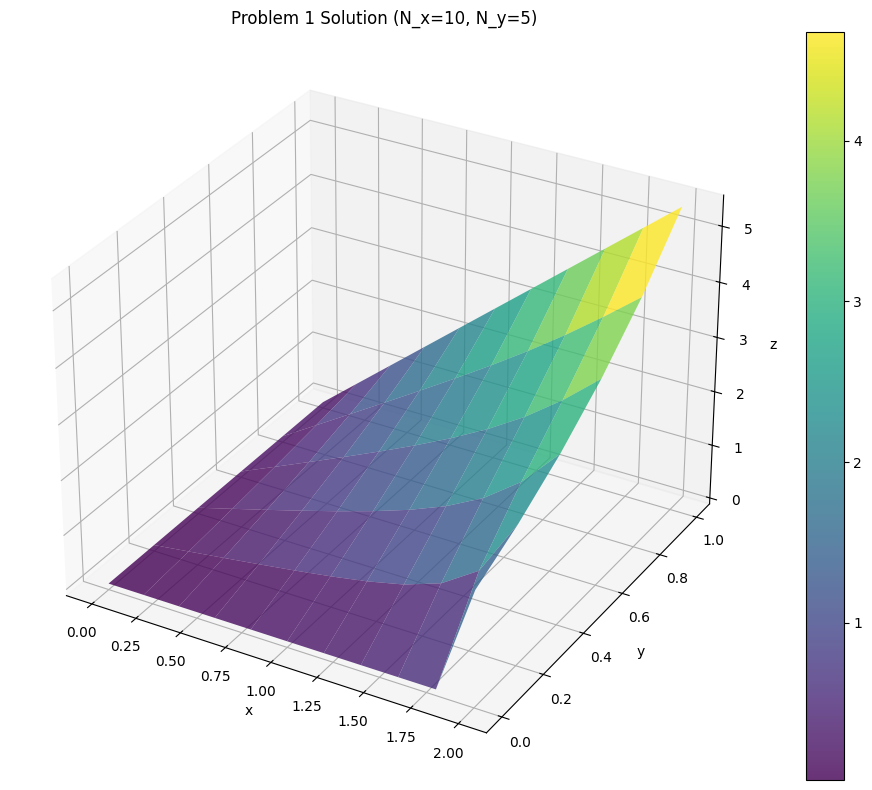

In [8]:
test_problem_1()